In [1]:
import sys
from pathlib import Path
import os
import scanpy as sc
import numpy as np

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

In [5]:
# PREPROCESS to anndata object from R sparse matrix and metadata (try subsampled first due to runtime issues)

from pathlib import Path
import pandas as pd
from scipy.io import mmread
from anndata import AnnData

base = Path("data/cd4_t_cells")
proc = base / "processed"

X = mmread(proc / "matrix_200k.mtx").tocsr().T
meta = pd.read_csv(proc / "metadata_200k.csv", index_col=0)

genes = pd.read_csv(proc / "genes.txt", header=None)[0].astype(str).values
barcodes = pd.read_csv(proc / "barcodes_200k.txt", header=None)[0].astype(str).values

adata = AnnData(X=X)
adata.obs_names = barcodes
adata.var_names = genes
adata.obs = meta.loc[adata.obs_names].copy()

print(adata)
print(adata.obs["Donor_id"].nunique())
print(adata.obs["Cluster_names"].value_counts())

adata.write_h5ad(proc / "blood_aging_cd4_200k.h5ad")

AnnData object with n_obs × n_vars = 200000 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'percent.mt', 'percent.ribo', 'log2_nCount', 'log2_nFeature', 'log2_mt', 'Donor_id', 'Age_group', 'Sex', 'Age', 'Tube_id', 'File_name', 'Batch', 'Cluster_numbers', 'Cluster_names'
166
Cluster_names
Naive                    102115
Tfh                       25514
Th2                       19216
Th17                      11795
Th1/Th17                  11433
Treg naive                 6825
Th22                       5637
Treg memory                4817
HLA-DR+ memory             3458
Temra                      2675
Naive-IFN                  2446
Terminal effector          1989
Th1                         922
Treg KLRB1+RORC+            806
Exhausted-like memory       294
Treg cytotoxic               58
Name: count, dtype: int64


Process dataset to be benchmark ready

In [2]:
from scrna_benchmark.embedding import (
    compute_hvg_subset,
    compute_pca,
    compute_harmony,
)

adata = sc.read_h5ad("data/cd4_t_cells/processed/blood_aging_cd4_200k.h5ad")

# filter rare classes
cell_counts = adata.obs["Cluster_names"].value_counts()
keep_celltypes = cell_counts[cell_counts >= 500].index

adata = adata[adata.obs["Cluster_names"].isin(keep_celltypes)].copy()

In [3]:
adata.raw = adata.copy()

adata = compute_hvg_subset(
    adata,
    n_top_genes=2000,
    batch_key="Donor_id",
)

adata = compute_pca(
    adata,
    n_comps=50,
    key_added="X_pca",
    random_state=42,
)

adata.obsm["X_pca_full"] = adata.obsm["X_pca"].copy()
adata.obsm["X_pca"] = adata.obsm["X_pca"][:, :15].copy()

adata = compute_harmony(
    adata,
    batch_col="Donor_id",
    basis="X_pca_full",
    key_added="X_harmony",
)

adata.obsm["X_harmony"] = adata.obsm["X_harmony"][:, :15].copy()

adata.write_h5ad("data/cd4_t_cells/processed/blood_aging_cd4_200k_benchmark_ready.h5ad")

2026-05-25 12:54:57,503 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-05-25 12:54:57,508 - harmonypy - INFO -   Parameters:
2026-05-25 12:54:57,510 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-25 12:54:57,513 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-25 12:54:57,515 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-25 12:54:57,516 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-25 12:54:57,518 - harmonypy - INFO -     nclust: 100
2026-05-25 12:54:57,520 - harmonypy - INFO -     block_size: 0.05
2026-05-25 12:54:57,525 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

In [2]:
from scrna_benchmark.config import DatasetConfig
from scrna_benchmark.pipeline import run_dataset_benchmark

adata_path = "data/cd4_t_cells/processed/blood_aging_cd4_200k_benchmark_ready.h5ad"

config = DatasetConfig(
    dataset_name="blood_aging_cd4_200k",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="Cluster_names",
    donor_col="Donor_id",
    batch_col=None,
    group_col="Batch",

    representations={
        "pca": "X_pca",
        "harmony": "X_harmony",
    },

    min_cells=500,
    min_donors=10,

    run_random_split=True,
    run_donor_cv=True,
    run_group_transfer=False,
    run_donor_ablation=True,

    donor_ablation_k_values=[10, 20, 40, 80, 120],
    donor_ablation_n_repeats=5,

    test_size=0.2,
    n_folds=5,
    random_state=42,
    save_filtered_adata=False,
    verbose=True,
)

outputs = run_dataset_benchmark(config)

Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)

Running donor ablation for pca (X_pca)
  k=10, repeat=1: macro_f1=0.5142, acc=0.7763
  k=10, repeat=2: macro_f1=0.5315, acc=0.7761
  k=10, repeat=3: macro_f1=0.5381, acc=0.7755
  k=10, repeat=4: macro_f1=0.5045, acc=0.7783
  k=10, repeat=5: macro_f1=0.5062, acc=0.7778
  k=20, repeat=1: macro_f1=0.5404, acc=0.7799
  k=20, repeat=2: macro_f1=0.5444, acc=0.7809
  k=20, repeat=3: macro_f1=0.5306, acc=0.7815
  k=20, repeat=4: macro_f1=0.5411, acc=0.7801
  k=20, repeat=5: macro_f1=0.5292, acc=0.7767
  k=40, repeat=1: macro_f1=0.5419, acc=0.7819
  k=40

In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

result_dir = Path("results/blood_aging_cd4_200k")

ablation = pd.read_csv(result_dir / "donor_ablation" / "donor_ablation_summary.csv")

print(ablation.columns)
print(ablation.head())

Index(['representation', 'rep_key', 'k_train_donors', 'macro_f1_mean',
       'macro_f1_std', 'accuracy_mean', 'accuracy_std', 'mean_train_cells',
       'mean_test_cells', 'mean_n_classes_used'],
      dtype='object')
  representation    rep_key  k_train_donors  macro_f1_mean  macro_f1_std  \
0        harmony  X_harmony              10       0.488775      0.007658   
1        harmony  X_harmony              20       0.498828      0.008128   
2        harmony  X_harmony              40       0.504558      0.005114   
3        harmony  X_harmony              80       0.501769      0.003343   
4        harmony  X_harmony             120       0.508479      0.003394   

   accuracy_mean  accuracy_std  mean_train_cells  mean_test_cells  \
0       0.761521      0.003743           11144.4         188503.6   
1       0.765077      0.003477           24257.4         175390.6   
2       0.767083      0.003205           51755.8         147892.2   
3       0.768259      0.003754           97227.6

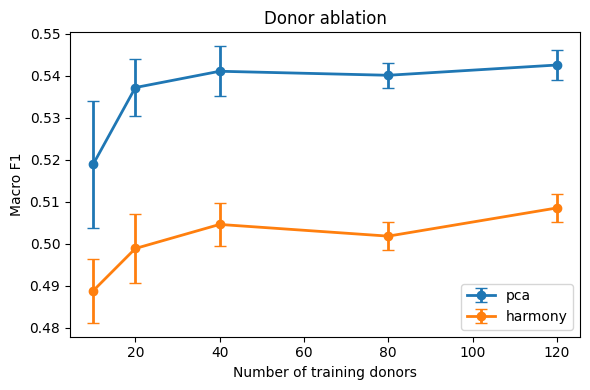

In [22]:
plt.figure(figsize=(6, 4))

for rep in ["pca", "harmony"]:
    sub = ablation[ablation["representation"] == rep].sort_values("k_train_donors")

    plt.errorbar(
        sub["k_train_donors"],
        sub["macro_f1_mean"],
        yerr=sub["macro_f1_std"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=rep,
    )

plt.xlabel("Number of training donors")
plt.ylabel("Macro F1")
plt.title("Donor ablation")
plt.legend()
plt.tight_layout()
plt.show()